In [45]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage

load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")


In [46]:
class TripDetails(BaseModel):
    origin: str | None = Field(
        default=None,
        description="Source or origin of the trip"
    )

    destination: str | None = Field(
        default=None,
        description="Destination of the trip"
    )

    battery_percentage_on_departure: int | None = Field(
        default=None,
        ge=0,
        le=100,
        description="Battery percentage of the car at departure"
    )

    is_round_trip: bool | None = Field(
        default=None,
        description="Whether the trip is a round trip"
    )

In [47]:
# state
class TripState(TypedDict):
    trip: TripDetails
    messages: list


In [48]:
structured_llm = llm.with_structured_output(TripDetails)

In [49]:
def gather_trip_details(state: TripState):

    prompt = f"""
        You are an intelligent EV trip-planning assistant.
        Have a natural conversation with the user and extract the required details from the user.

        Conversation:
        {state["messages"]}


    """
    trip_details = structured_llm.invoke(prompt)

    return {
        "trip": trip_details
    }

In [50]:
graph = StateGraph(TripState)

graph.add_node("gather_trip_details", gather_trip_details)

In [51]:
graph.add_edge(START, "gather_trip_details")
graph.add_edge("gather_trip_details", END)

In [52]:
app = graph.compile()

In [53]:
result = app.invoke({
    "messages": [
        HumanMessage(
            content="I want to travel from Pune to Mumbai, and my car battery is 50%"
        )
    ],
    "trip": TripDetails()
})

print(result)

{'trip': TripDetails(origin='Pune', destination='Mumbai', battery_percentage_on_departure=50, is_round_trip=None), 'messages': [HumanMessage(content='I want to travel from Pune to Mumbai, and my car battery is 50%', additional_kwargs={}, response_metadata={})]}


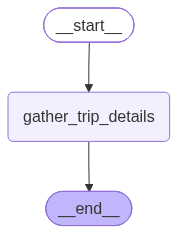

In [54]:
app